In [1]:
%load_ext autoreload
%autoreload 2

# Static autoencoder performance as a function of neurons' probabilistic dropout

In [2]:
import torch
from wassa_functions import performance_as_a_function_of_dataset_parameters
from dataset_generation import get_dataset_parameters
from wassa_training import get_training_parameters
from wassa_plots import plot_results_std
import matplotlib.pyplot as plt
import numpy as np

In [3]:
date = '2025-10-15'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
device = 'cuda:0'

In [5]:
dataset_parameters = {
    'seed' : 92,
    
    'N_pre' : 300, # number of neurons
    'N_timesteps' : 250, # number of timesteps for the raster plot (in ms)
    'N_samples' : 30, # total number of samples in the dataset
    'N_SMs' : 1, # number of structured spiking motifs
    'N_delays' : 250, # number of timesteps in spiking motifs, must be a odd number for convolutions
    'overlapping_sms' : False, # possibility to have overlapping sequences

    'temporal_jitter' : 0, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'warping_coef' : 1, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_SMs'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'freq_sms' : 1000*torch.ones(dataset_parameters['N_SMs'],device=device)}) # frequency of apparition of the different spiking motifs (in Hz)
dataset_parameters.update({'frs' : 4*torch.ones(dataset_parameters['N_pre'],device=device)})
dataset_parameters.update({'coefficient_variation' : 1*torch.ones(dataset_parameters['N_pre'],device=device)}) # coefficient of variation of the FRs of each neuron (within VS. without a motif)

In [6]:
training_parameters_emd = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'topk' : None,
    'kernels_norm' : True,
    'N_learnsteps' : 2000,
    'learning_rate' : .1,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : [False, False, False],
    'weight_init' : 'flat',
    'tied_weights' : True,
    'normalize_input' : True
}

In [7]:
training_parameters_mse = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'topk' : None,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : [False, False, False],
    'weight_init' : 'flat',
    'tied_weights' : True,
    'normalize_input' : True
}

In [8]:
dataset_variables = {
'dropout_proba' : torch.linspace(0,.9,10).tolist(),
}

In [9]:
file_name_emd = '../simulations/results_dropout_last'+get_training_parameters(training_parameters_emd)
file_name_mse = '../simulations/results_dropout_last'+get_training_parameters(training_parameters_mse)
training_metrics = ['training loss', 'testing loss', 'explained variance']
synthetic_metrics = ['kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings']
n_iter = 100
kfold = 1
do_seqnmf = False
results_emd, _ = performance_as_a_function_of_dataset_parameters(file_name_emd, dataset_parameters, training_parameters_emd, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)
results_mse, _ = performance_as_a_function_of_dataset_parameters(file_name_mse, dataset_parameters, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

TypeError: plot_results_std() got an unexpected keyword argument 'xmax'

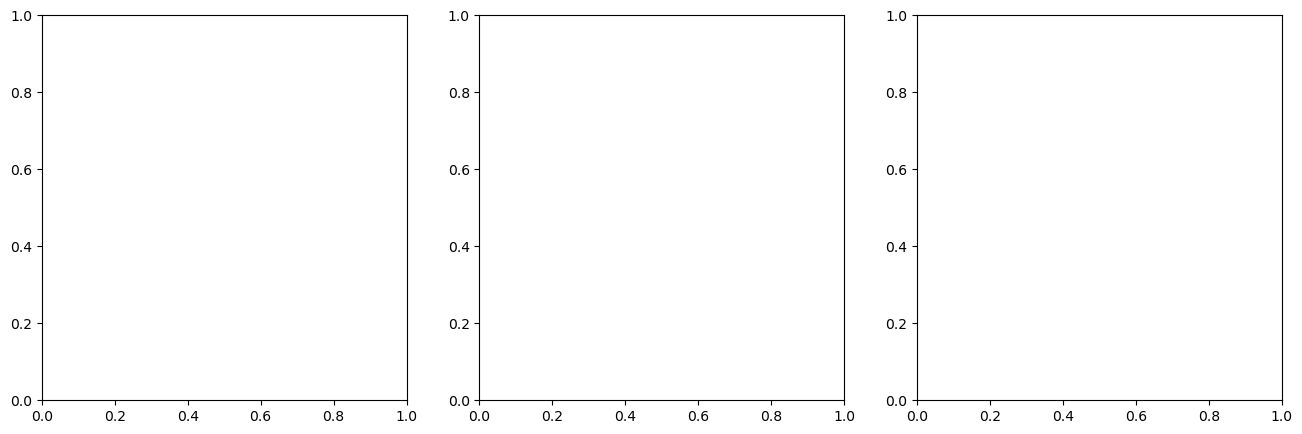

In [10]:
name_metrics = ['kernels similarity', 'mean timings similarity', 'mean time diff']
name_methods = ['MSE','EMD']
colors = ['darkolivegreen','blue','purple','orangered']
xlabel = 'dropout probability'
quantile = True

fig, ax = plt.subplots(1,3, figsize=(16,5))
for i in range(len(name_metrics)):
    for m in range(len(name_methods)):
        ymin, ymax = 0, 1.01
        xmin, xmax = 0, .91
        do_legend, log_x, log_y = False, False, False
        if i==0:
            ylabel = 'similarity value'
        elif i==2:
            ylabel = 'averaged timing difference'
            ymin, ymax = 0, None
            log_y = False
        else:
            ylabel = None
            do_legend = True
        ax[i] = plot_results_std(ax[i],results_emd[:,m],dataset_variables['dropout_proba'],name_metrics[i],xlabel,name_metrics[i],name_methods[m],colors[m],ymax=ymax,ymin=ymin,xmax=xmax,xmin=xmin,ylabel=ylabel,do_legend=do_legend,log_x=log_x,log_y=log_y,quantile=quantile,plot_all_points=False)

In [ ]:
fig.tight_layout()
fig.savefig('../figures/results_spontaneous_static.pdf', bbox_inches = 'tight')

In [ ]:
results_emd.shape